<p align="center">
<img src="Images/sorbonne_logo.png" alt="Logo" width="300"/>
</p>

# **Module 5 - FC-FAVAR**

* **Author**: Elia Landini
* **Student ID**: 12310239
* **Course**: EESM3-Financial Economics 
* **Supervisor**: Jean-Bernard Chatelain
* **Reference Repository**: https://github.com/EliaLand/IRL-FAVAR_money_endogeneity

### **1) REQUIREMENTS SET-UP**

In [61]:
# Requirements.txt file installation
# !pip install -r requirements.txt

In [62]:
# Libraries import
import warnings
import pandas as pd
import numpy as np
import numpy.linalg as la
import random
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
%matplotlib inline
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import levene
from scipy.stats import ks_2samp
from scipy.stats import kstest
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.api import VAR
from scipy.linalg import eigvals, cholesky
from sklearn.decomposition import PCA
import sklearn.tree
import sklearn.metrics
import sklearn.metrics
import sklearn.model_selection
import sklearn.preprocessing 
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, precision_recall_curve, auc, 
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
import plotly.express as px
import plotly.graph_objects as go
import openpyxl as pxl
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML
from IPython.display import Image
import itertools
from arch.unitroot import PhillipsPerron
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import MaxNLocator

### **2) DATA IMPORT**

In [63]:
# Raw df import
jp_aggregated_df = pd.read_csv("Data/Aggregated/jp_aggregated_df.csv")
jp_aggregated_df

,Country,Time,Monetary Aggregates - M1 (JPY),Monetary Aggregates - M2 (JPY),Monetary Aggregates - M3 (JPY),Total Credit - Private Non-Financial (%GDP),Total Credit - General Government (%GDP),Total Credit - Households & NPISHs (%GDP),Total Treasury Reserves (- Gold),10-Year Gov Bond Yields (%),...,Real GDP (billions chained 2015 JPY),Central Government Debt (% GDP),Domestic Private Debt Securities (% GDP),Domestic Public Debt Securities (% GDP),BoJ’s Total Assets (100 Million Yen),Loan Interest Rate (%),Deposit Interest Rate (%),1615.T-Price,10-Year US T-Bills Yield (%),CBOE-VIX
0,JP,1950-12,NaN,NaN,NaN,NaN,NaN,NaN,5.980000e+02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,JP,1951-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,JP,1951-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,JP,1951-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,JP,1951-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,JP,2025-12,NaN,NaN,NaN,NaN,NaN,NaN,1.252603e+06,2.06,...,591856.7,NaN,NaN,NaN,6777762.0,1.404,0.225,528.200012,4.143182,15.548182
901,JP,2026-01,NaN,NaN,NaN,NaN,NaN,NaN,1.259248e+06,2.24,...,NaN,NaN,NaN,NaN,6828680.0,NaN,0.227,598.299988,4.213500,16.179048
902,JP,2026-02,NaN,NaN,NaN,NaN,NaN,NaN,1.268656e+06,2.11,...,NaN,NaN,NaN,NaN,6837705.0,NaN,0.296,647.900024,4.125789,19.207000
903,JP,2026-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6621318.0,NaN,NaN,NaN,4.245909,25.596818


In [64]:
# Transformed df import
jp_trans_df = pd.read_csv("Data/Transformed/jp_trans_df.csv")
jp_trans_df

,Country,Time,LogDiff-Monetary Aggregates - M1 (JPY),LogDiff-Monetary Aggregates - M2 (JPY),LogDiff-Monetary Aggregates - M3 (JPY),LogDiff-Total Treasury Reserves (- Gold),LogDiff-USD-JPY reer CPI-based (Index 2015=100),LogDiff-JPY-USD Spot Exchange Rate,LogDiff-HICP (SA),LogDiff-1615.T-Price,...,AR(1)detrend-Est. 1-year Neutral Interest Rate (%),AR(1)detrend-Est. 10-year Neutral Interest Rate (%),AR(1)detrend-Central Government Debt (% GDP),AR(1)detrend-Domestic Private Debt Securities (% GDP),AR(1)detrend-Domestic Public Debt Securities (% GDP),AR(1)detrend-Loan Interest Rate (%),AR(1)detrend-Deposit Interest Rate (%),AR(1)detrend-10-Year US T-Bills Yield (%),AR(1)detrend-CBOE-VIX,HPfilter-Real GDP (billions chained 2015 JPY)
0,JP,1950-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,JP,1951-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,JP,1951-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,JP,1951-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,JP,1951-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,JP,2025-12,NaN,NaN,NaN,0.005796,-0.012713,0.004976,NaN,0.043927,...,0.002655,0.002863,NaN,NaN,NaN,0.264511,0.004569,0.041303,-4.174574,-0.001618
901,JP,2026-01,NaN,NaN,NaN,0.005291,-0.012815,0.004706,NaN,0.124617,...,NaN,NaN,NaN,NaN,NaN,NaN,0.006569,0.062548,0.033351,NaN
902,JP,2026-02,NaN,NaN,NaN,0.007443,0.000443,-0.009937,NaN,0.079644,...,NaN,NaN,NaN,NaN,NaN,NaN,0.073583,-0.095167,2.526720,NaN
903,JP,2026-03,NaN,NaN,NaN,NaN,NaN,0.022826,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112272,6.350713,NaN


### **3) DATA PREP & EXTRACTION**

In [65]:
# Df import 
# (!!!) We use stationary transformed variables, both policy target, like usual and LogDiff transformed policy instrument ("LogDiff-Call Money/Interbank Immediate (%)")
jp_trans_df = pd.read_csv("Data/Transformed/jp_trans_df.csv")

df = jp_trans_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")
# (!!!) Remember to take those -inf or inf values out
df = df.replace([np.inf, -np.inf], np.nan)

In [66]:
# Variables Filtering for Factors Construction
# (!!!) We keep only time as index, and relevant variables, we exclude "Country", as well as other target variables proxies  
# (!!!) Doubled AR(1)detrend-Call Money/Interbank Immediate (%), we drop it, we keep only log diff
# (!!!) Drop 1615.T-Price — ETF only available from 2008, limits the full sample window
favar_vars = [col for col in df.columns if col not in [
    "Country",
    "AR(1)detrend-Call Money/Interbank Immediate (%)",
    "LogDiff-1615.T-Price",
]]
favar_df_raw = df[favar_vars].copy()

# (!!!) Keep only variables with data going at least until 2021
cutoff = pd.Timestamp("2021-01-01")
cols_until_2021 = [
    col for col in favar_df_raw.columns
    if favar_df_raw[col].last_valid_index() is not None
    and favar_df_raw[col].last_valid_index() >= cutoff
]

favar_df = favar_df_raw[cols_until_2021].copy()

# (!!!) NaN filling: slice from latest first_valid to end of 2023, then ffill → bfill
first_valid = max(favar_df[col].first_valid_index() for col in favar_df.columns)
end_date = pd.Timestamp("2023-12-01")
favar_df = favar_df.loc[first_valid:end_date].ffill().bfill().copy()

favar_df

,LogDiff-Monetary Aggregates - M1 (JPY),LogDiff-Monetary Aggregates - M3 (JPY),LogDiff-Total Treasury Reserves (- Gold),LogDiff-USD-JPY reer CPI-based (Index 2015=100),LogDiff-JPY-USD Spot Exchange Rate,LogDiff-HICP (SA),LogDiff-BoJ’s Total Assets (100 Million Yen),LogDiff-Call Money/Interbank Immediate (%),AR(1)detrend-Total Credit - General Government (%GDP),AR(1)detrend-Total Credit - Households & NPISHs (%GDP),AR(1)detrend-Total Credit - Private Non-Financial (%GDP),AR(1)detrend-10-Year Gov Bond Yields (%),AR(1)detrend-Est. 1-year Neutral Interest Rate (%),AR(1)detrend-Est. 10-year Neutral Interest Rate (%),AR(1)detrend-Central Government Debt (% GDP),AR(1)detrend-Loan Interest Rate (%),AR(1)detrend-Deposit Interest Rate (%),AR(1)detrend-10-Year US T-Bills Yield (%),AR(1)detrend-CBOE-VIX,HPfilter-Real GDP (billions chained 2015 JPY)
Time,,,,,,,,,,,,,,,,,,,,
1998-05-01,-0.001478,0.004179,0.005912,-0.009257,0.023571,1.032947,-0.036587,-0.035448,-0.871817,-0.004204,0.037320,-0.205574,0.005916,0.007286,-0.439234,-0.008782,-0.094829,0.013768,-0.763047,-0.007774
1998-06-01,0.005891,0.000768,-0.005285,-0.020954,0.039496,-0.427880,-0.023495,0.020655,-0.871817,-0.004204,0.037320,-0.110000,0.005916,0.007286,-0.439234,0.019155,0.013456,-0.157183,1.004040,-0.006858
1998-07-01,0.008248,0.004922,0.009074,-0.008351,0.003251,-3.399241,-0.040035,-0.055638,1.928183,0.095796,1.337320,0.147226,-0.064084,-0.083714,-0.439234,0.056026,0.100502,-0.036742,-1.397038,-0.004739
1998-08-01,0.007263,0.004464,0.008834,-0.034016,0.027273,-4.032639,0.052921,0.033228,-0.850757,-0.003848,0.041528,-0.175812,0.005752,0.007033,-0.439234,-0.004911,0.082153,-0.121357,11.729335,-0.004053
1998-09-01,0.005014,0.003470,0.012959,0.067334,-0.073105,5.911240,0.025754,-0.284114,-0.850757,-0.003848,0.041528,-0.395030,0.005752,0.007033,-0.439234,-0.010845,-0.206328,-0.537668,8.467168,-0.003498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-01,0.004397,0.001555,-0.001442,-0.011559,0.026912,0.875398,0.009292,-0.847298,-0.003841,-0.023430,-0.041017,0.042867,0.002507,0.002626,-0.633651,-0.050724,0.001043,0.259471,1.077413,-0.006225
2023-09-01,0.003551,0.000988,-0.010040,-0.011008,0.020946,4.881098,-0.009458,-0.847298,-0.003841,-0.023430,-0.041017,0.123170,0.002507,0.002626,-0.633651,0.264181,0.003029,0.203514,-1.231434,-0.006145
2023-10-01,0.003168,0.001917,-0.002267,-0.004669,0.011756,7.955824,0.012277,-0.847298,-0.203841,-0.423430,-0.541017,0.184011,0.000507,0.000626,-0.633651,-0.188735,0.003029,0.412376,3.059669,-0.000900


In [67]:
# PCA (Data Compression)
# (!!!) We can't find 23 variables into a VAR, or it would lead to degrees of freedom issue, so we use pca to create 5 super factors (variables) to plug in
# (!!!) These Factors summarize everything a CB has control on or can monitor
# (!!!) F1-F5 are UNCORRELATED (no multicollinearity), from 23 variables, to 5 uncorrelated 

# 5 factors PCA
pca = PCA(n_components=5) 
pca5_factors = pca.fit_transform(favar_df.values)

# Factors numbering 
factors_df = pd.DataFrame(
    pca5_factors, 
    index=favar_df.index, 
    columns=[f"F{i+1}" for i in range(5)]
)

# (!!!) Explained variance 
# (!!!) cumulative sum by adding one factor at a time of how much info we kept, the biggest jump is from 1 to 2 factors
print("Explained variance:", pca.explained_variance_ratio_.cumsum())

Explained variance: [0.51622924 0.75866504 0.88796958 0.95922455 0.98994037]


### **4)  Y TARGET VARIABLES & SMOOTHING VARIABLE Z**

In [68]:
# Target Variables Y
Y_vars = [
# Monetary Aggregate
    "LogDiff-Monetary Aggregates - M3 (JPY)",   
# Credit Demand 
    "AR(1)detrend-Total Credit - Private Non-Financial (%GDP)",
# LogDiff-Call Money/Interbank Immediate (%) (Regime Induction)
    "LogDiff-Call Money/Interbank Immediate (%)"
]
# Target Variables Aggregation
# (!!!) Forward filling of nan 
Y = df[Y_vars].reindex(factors_df.index).fillna(method="ffill")

# Final FVAR df
# P_t = [Y1,Y2, F1,F2,F3,F4,F5]
favar_core_df = pd.concat([Y, factors_df], axis=1).dropna()
favar_core_df

C:\Users\eland\AppData\Local\Temp\ipykernel_19196\2139645218.py:12: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



,LogDiff-Monetary Aggregates - M3 (JPY),AR(1)detrend-Total Credit - Private Non-Financial (%GDP),LogDiff-Call Money/Interbank Immediate (%),F1,F2,F3,F4,F5
Time,,,,,,,,
1998-05-01,0.004179,0.037320,-0.035448,-0.886247,0.845534,-0.596586,-0.637813,0.411149
1998-06-01,0.000768,0.037320,0.020655,0.929184,-0.541004,-0.807410,-0.710747,0.426855
1998-07-01,0.004922,1.337320,-0.055638,-1.421564,-3.845818,-0.673152,2.041432,0.675458
1998-08-01,0.004464,0.041528,0.033228,11.762896,-3.779776,-1.154547,-0.787628,0.500969
1998-09-01,0.003470,0.041528,-0.284114,8.181353,5.891673,0.498084,-0.179812,0.431423
...,...,...,...,...,...,...,...,...
2023-08-01,0.001555,-0.041017,-0.847298,0.944674,0.688975,-0.505166,0.187222,0.058378
2023-09-01,0.000988,-0.041017,-0.847298,-1.493225,4.556408,0.133103,0.413587,0.017641
2023-10-01,0.001917,-0.541017,-0.847298,2.697462,7.726905,0.752523,0.271050,-0.416826


In [69]:
# AIC for lag order selection 
model = VAR(Y)
lag_order = model.select_order(maxlags=10)
print(lag_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -13.96      -13.92   8.675e-07      -13.94
1       -14.98      -14.83   3.134e-07      -14.92
2       -15.37      -15.11   2.107e-07      -15.27
3       -15.50     -15.13*   1.858e-07     -15.35*
4      -15.51*      -15.03  1.837e-07*      -15.32
5       -15.48      -14.88   1.898e-07      -15.24
6       -15.51      -14.80   1.845e-07      -15.22
7       -15.48      -14.66   1.902e-07      -15.15
8       -15.48      -14.55   1.902e-07      -15.10
9       -15.50      -14.46   1.863e-07      -15.08
10      -15.49      -14.34   1.875e-07      -15.03
--------------------------------------------------


d:\Conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



In [70]:
# Smoothing Varible - Monetary Policy Regime Indicator (YCC proxy)
# (!!!) We can use the lag of the boj assets to define whether the VAR runs under a monetary policy period of tightness or looseness, or like under ycc
# (!!!) Comments to be made especially during the period of YCC

# 6 Lags Boj Call Rate - Smoothing Variable
# (!!!) LogDiff-BoJ’s Call Rate, 6 months lag
Z = favar_core_df["LogDiff-Call Money/Interbank Immediate (%)"].shift(6).dropna()  
reg_favar_core_df = favar_core_df.loc[Z.index]

# Low-High Policy Regimes
# (!!!) As in the paper, we identify 4 policy regimes 
z_grid = np.percentile(Z, [20,40,60,80])  
z_grid

array([-0.84729786, -0.14590296,  0.        ,  0.01046771])

In [71]:
# PCA-Derived Factor Explained Variance per Dependent Variable (FC-FAVAR)

# Dependent Variable
dep_vars  = [
    "LogDiff-Monetary Aggregates - M3 (JPY)",
    "AR(1)detrend-Total Credit - Private Non-Financial (%GDP)",
    "LogDiff-Call Money/Interbank Immediate (%)"
]
dep_labels = ["M3 (LogDiff)", "Credit/GDP\n(AR1-detrend)", "Call Money\n(LogDiff)"]
factor_cols = ["F1", "F2", "F3", "F4", "F5"]

# R-squared 
def r2_ols(x, y):
    X = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
# R-Squared Matrix
r2_matrix = np.zeros((len(factor_cols), len(dep_vars)))
for j, dv in enumerate(dep_vars):
    y = favar_core_df[dv].dropna().values
    for i, fk in enumerate(factor_cols):
        x_raw = favar_core_df[fk].reindex(favar_core_df[dv].dropna().index).values
        mask  = ~np.isnan(x_raw) & ~np.isnan(y)
        r2_matrix[i, j] = r2_ols(x_raw[mask], y[mask])
r2_df = pd.DataFrame(r2_matrix, index=factor_cols, columns=dep_labels)

# Log-transform for color mapping only 
eps = 1e-4
z_log = np.log10(np.maximum(r2_matrix, eps))

# Text Annotation 
text_annot = [[f"{r2_matrix[i,j]:.3f}" for j in range(len(dep_vars))]
              for i in range(len(factor_cols))]
# Color Rescaling
fig = go.Figure(
    data=go.Heatmap(
        z = z_log,           
        x = dep_labels,
        y = factor_cols,
        text = text_annot,
        texttemplate = "%{text}",
        textfont = dict(size=14),
        colorscale = "Viridis",
        colorbar = dict(
            title = dict(text="R² (log₁₀)", font=dict(size=11, color="black")),
            tickformat = ".1f",
            tickvals = [-4, -3, -2, -1, 0],
            ticktext = ["0.0001", "0.001", "0.01", "0.1", "1.0"],
            tickfont = dict(size=10, color="black"),
        ),
    )
)
# Figure Layout & Cosmetics
fig.update_layout(
    title=dict(
        text=(
            "PCA-Derived Factor Explained Variance per Dependent Variable (FC-FAVAR)<br>"
            "<span style='font-size:11px;font-weight:normal;color:black'>"
            "R² of regressing each target on each PCA factor individually"
            "</span>"
        ),
        x=0.5, xanchor="center",
        font=dict(size=13, color="black"),
    ),
    xaxis=dict(
        title=dict(text="Dependent Variable", font=dict(size=11, color="black")),
        tickfont=dict(size=10, color="black"),
    ),
    yaxis=dict(
        title=dict(text="PCA Factor", font=dict(size=11, color="black")),
        tickfont=dict(size=10, color="black"),
        autorange="reversed",
    ),
    width=700, height=500,
    margin=dict(l=80, r=40, t=100, b=80),
    font=dict(size=11, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
)
fig.show()

### **5) STABILITY CONTROL & COMPANION MATRIX**

In [72]:
# Local FAVAR
# (!!!) Optimal Lag Order from AIC Order Selection
lag = 4
K = favar_core_df.shape[1]
results = {}

for i, z0 in enumerate(z_grid):
# Local weights 
# (!!!) We rescale through local weights the different regions of the Z smoothing factor to prioritize observations close to zero
    h = 0.1 * np.std(Z)
# Gaussian Rescaling
    kern = np.exp(-0.5 * ((Z - z0)/h)**2) / (h * np.sqrt(2 * np.pi))
    K_w = kern.iloc[1:].values / kern.iloc[1:].sum()


# VAR data
# Smoothing factor
    wvar_data = reg_favar_core_df.values[1:]
    n = wvar_data.shape[0]
# Regressors and target
    X = np.ones((n - lag, (lag + 1) * K))
    y_list = []
# Lag Matrix X
    for t in range(lag, n):
        y_list.append(wvar_data[t])
        for q in range(1, lag + 1):
            X[t - lag, q*K:(q+1)*K] = wvar_data[t - q]
    y = np.array(y_list)
    weights = np.diag(np.sqrt(K_w[lag:]))


# Rescaled Weighted OLS
    X_w = weights @ X
    y_w = weights @ y
    beta = la.pinv(X_w.T @ X_w) @ (X_w.T @ y_w)
# Reshaping to VAR matrices
    Phi_z0 = beta.reshape(lag + 1, K, K)
    results[z0] = Phi_z0

    print(f"z0={z0:.3f}: AR(1) diags {np.diag(Phi_z0[1])[:4].round(3)}...")

print("Roots check (avg A1):", np.abs(eigvals(np.mean([r[1] for r in results.values()],0))))

z0=-0.847: AR(1) diags [ 0.581  1.162  0.404 -0.256]...
z0=-0.146: AR(1) diags [-0.207 -0.593  0.517  0.148]...
z0=0.000: AR(1) diags [ 0.231 -0.503  0.242  0.14 ]...
z0=0.010: AR(1) diags [ 0.23  -0.42   0.237  0.146]...
Roots check (avg A1): [0.41080235 0.23057181 0.23057181 0.12606531 0.12606531 0.0965768
 0.0965768  0.05479337]


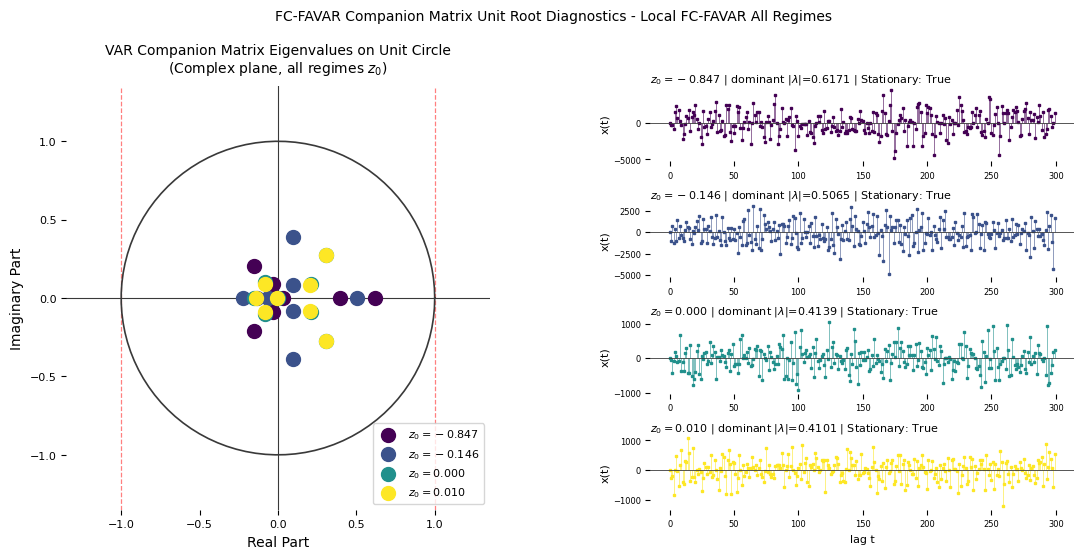

In [73]:
# FC-FAVAR Companion-Matrix Unit-Root Circle Plotting

# General settings & Parameters
# We extract eigenvalues and parameters from the Local FAVAR estimated companion matrices
core_variables = [f"$z_0={z0:.3f}$" for z0 in z_grid]
# Eigenvalues of Phi_1 companion matrix for each regime
eigenvalues_per_regime = {z0: eigvals(results[z0][1]) for z0 in z_grid}
# Dominant eigenvalue (largest modulus) per regime — VAR analog of AR(1) coefficient
dominant_eigs = np.array([
    eigenvalues_per_regime[z0][np.argmax(np.abs(eigenvalues_per_regime[z0]))]
    for z0 in z_grid
])
# Stationarity flag: all eigenvalues inside unit circle
stationary = [
    all(np.abs(eigenvalues_per_regime[z0]) < 1.0) for z0 in z_grid
]
# Angle of the circle
theta = np.linspace(0, 2 * np.pi, 100)
# Color Palette
palette = ["#440154", "#3B528B", "#21908C", "#FDE725"]
colors  = [palette[i % len(palette)] for i in range(len(core_variables))]
# Figure settings
fig = plt.figure(figsize=(13, 5.5), facecolor="#ffffff")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)


# Unit Root Circle
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#ffffff")

# Plot components:
# 1) Unit circle
ax1.plot(np.cos(theta), np.sin(theta), color="#393939", lw=1.2, zorder=1)
# 2) Vertical and horizontal axes (0,0)
ax1.axhline(0, color="#393939", lw=0.8, zorder=0)
ax1.axvline(0, color="#393939", lw=0.8, zorder=0)
# 3) +1, -1 Vertical Stationarity limits (-1, +1)
ax1.axvline(1.0,  color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)
ax1.axvline(-1.0, color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)

# Variables lambda on the circle
# VAR eigenvalues can be complex — plot real vs imaginary parts in the complex plane
for i, (z0, var, col) in enumerate(zip(z_grid, core_variables, colors)):
    eigs = eigenvalues_per_regime[z0]
# (!!!) To plot the lambda point we can use the scatter function
    ax1.scatter(eigs.real, eigs.imag,
                color=col, s=100, zorder=4, linewidths=1.0, label=var)

# Subplot settings
# (!!!) Set .set_aspect to "equal" and not "auto" or it deforms the unit root circle into an ellipse
ax1.set_xlim(-1.35, 1.35)
ax1.set_ylim(-1.35, 1.35)
ax1.set_aspect("equal")
ax1.set_title("VAR Companion Matrix Eigenvalues on Unit Circle\n(Complex plane, all regimes $z_0$)", pad=10, fontsize=10)
ax1.set_xlabel("Real Part")
ax1.set_ylabel("Imaginary Part")
ax1.tick_params(labelsize=8)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.legend(loc="lower right", fontsize=8)


# Simulated FAVAR processes
# Grid settings
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)
gs_right = gridspec.GridSpecFromSubplotSpec(
    len(core_variables), 1,
    subplot_spec=gs[1],
    hspace=0.55
)

# Simulation Parameters
# Random seed
np.random.seed(42)
# Number of steps to simulate
N = 300
K = favar_core_df.shape[1]

# Simulation Plotting
for i, (z0, var, col, stat) in enumerate(zip(z_grid, core_variables, colors, stationary)):
    ax = fig.add_subplot(gs_right[i])
    ax.set_facecolor("#ffffff")
    Phi1 = results[z0][1]
    Phi2 = results[z0][2]
# Simulation of the VAR(2) process: y_t = Phi1 @ y_{t-1} + Phi2 @ y_{t-2} + u_t
# We plot the first variable's trajectory as representative
    eps = np.random.normal(0, 1, (N, K))
    Y = np.zeros((N, K))
    Y[0] = eps[0]
    Y[1] = Phi1 @ Y[0] + eps[1]
    for t in range(2, N):
        Y[t] = Phi1 @ Y[t - 1] + Phi2 @ Y[t - 2] + eps[t]
    y = Y[:, 0]
# Stem-style plot (squared dots with horizontal lines to the 0 axis)
    markerline, stemlines, baseline = ax.stem(
        np.arange(N), y,
        linefmt=col,
        markerfmt=f"s",
        basefmt=" "
    )
    plt.setp(stemlines, lw=0.4, alpha=1, color=col)
    plt.setp(markerline, markersize=2.0, color=col, alpha=1)
# Horizontal zero line
    ax.axhline(0, color="#393939", lw=0.6)
# Cosmetics
    dom_mod = np.max(np.abs(eigenvalues_per_regime[z0]))
    ax.set_title(
        f"{var} | dominant $|\\lambda|$={dom_mod:.4f} | Stationary: {stat}",
        fontsize=8, loc="left", pad=3
    )
# ylabel: x(t)
    ax.set_ylabel("x(t)", fontsize=8, labelpad=2)
    ax.tick_params(labelsize=6)
    for spine in ax.spines.values():
        spine.set_visible(False)
# xlabel (we only plot the x label on the last bottom subplot)
    if i == len(core_variables) - 1:
        ax.set_xlabel("lag t", fontsize=8)


plt.suptitle("FC-FAVAR Companion Matrix Unit Root Diagnostics - Local FC-FAVAR All Regimes", fontsize=10, y=1.02)
plt.show()

### **6) LOCAL REGIME-SHIFTING FC-FAVAR ESTIMATION**

In [74]:
# Local Regime-Shifting FC-FAVAR Estimation

# Lag Optimized from CAIC
lag = 3
K = favar_core_df.shape[1]
zgrid = np.percentile(Z, [20, 40, 60, 80])
results = {}

# Loop over zgrid
for i, z0 in enumerate(zgrid):
# (!!!) Regime-shifter functional coefficient Z rescaling  
    h = 0.1 * np.std(Z)
    kern = np.exp(-0.5 * ((Z - z0) / h) ** 2) / (h * np.sqrt(2 * np.pi))
    Kw = kern.iloc[1:].values / kern.iloc[1:].sum()
    wvardata = reg_favar_core_df.values[1:]
    n = wvardata.shape[0]

# (!!!) Lagged Factorized Regressors 
    X = np.ones((n - lag, lag * K + 1))
    for q in range(1, lag + 1):
        X[:, (q - 1) * K + 1 : q * K + 1] = wvardata[lag - q : n - q]
# (!!!) Xw and yw weights
    y = wvardata[lag:]
    weights = np.diag(np.sqrt(Kw[lag:]))
    Xw = weights @ X
    yw = weights @ y
    beta = la.pinv(Xw.T @ Xw) @ Xw.T @ yw

# (!!!) Phi
    Phi_z0 = beta[1:].reshape(lag, K, K)
    results[z0]  = Phi_z0

# Regime dependent results
    print(f"\n{'='*40}")
    print(f"REGIME z0 = {z0:.4f}  (Regime {i+1} of {len(zgrid)})")
    print(f"{'='*40}")
    for l in range(lag):
        print(f"\n  Phi_{l+1}  [AR lag-{l+1} coefficient matrix]:")
        print(pd.DataFrame(
            Phi_z0[l].round(4),
            index=favar_core_df.columns,
            columns=favar_core_df.columns
        ).to_string())


REGIME z0 = -0.8473  (Regime 1 of 4)

  Phi_1  [AR lag-1 coefficient matrix]:
                                                          LogDiff-Monetary Aggregates - M3 (JPY)  AR(1)detrend-Total Credit - Private Non-Financial (%GDP)  LogDiff-Call Money/Interbank Immediate (%)        F1       F2        F3        F4      F5
LogDiff-Monetary Aggregates - M3 (JPY)                                                    0.5595                                                  -44.7496                                     -0.0357 -143.4225  46.6960 -483.9275 -177.0780 -9.1223
AR(1)detrend-Total Credit - Private Non-Financial (%GDP)                                  0.0058                                                    0.4689                                      0.0156    0.3145   4.1437    1.1202    1.8918 -0.0995
LogDiff-Call Money/Interbank Immediate (%)                                               -0.0019                                                   -2.5331                             

In [75]:
# Granger Causality - Credit and Money Supply (M3)

# Column indices for the two variables of interest
cols = favar_core_df.columns.tolist()
M3_idx = cols.index("LogDiff-Monetary Aggregates - M3 (JPY)")
credit_idx = cols.index("AR(1)detrend-Total Credit - Private Non-Financial (%GDP)")

# Preface Print
print("\n" + "="*50)
print("Granger Causality: M3 <--> Credit  (by Regime)")
print("Null H0: lags of X do NOT Granger-cause Y")
print("="*50)

# (!!!) We re-run estimation to get residuals for each regime
for i, z0 in enumerate(zgrid):
# (!!!) Same as before
    h = 0.1 * np.std(Z)
    kern = np.exp(-0.5 * ((Z - z0) / h) ** 2) / (h * np.sqrt(2 * np.pi))
    Kw = kern.iloc[1:].values / kern.iloc[1:].sum()
    wvardata = reg_favar_core_df.values[1:]
    n = wvardata.shape[0]
    X = np.ones((n - lag, lag * K + 1))
    for q in range(1, lag + 1):
        X[:, (q - 1) * K + 1 : q * K + 1] = wvardata[lag - q : n - q]
    y = wvardata[lag:]
    weights = np.diag(np.sqrt(Kw[lag:]))
    Xw = weights @ X
    yw = weights @ y
    beta = la.pinv(Xw.T @ Xw) @ Xw.T @ yw
    Phi_z0 = results[z0]
    df_resid = X.shape[0] - X.shape[1]

# Granger Causality Test Function Manual Definition
    def granger_f_test(cause_idx, effect_idx):
# (!!!) Restricted model: we remove all lags of "cause" from "effect" equation
# (!!!) Unrestricted: full model
# (!!!) Col indices of "cause" lags in X: positions 1 + l*K + cause_idx, l=0..lag-1
        cause_cols = [1 + l * K + cause_idx for l in range(lag)]

# Unrestricted fit
        beta_full = la.pinv(Xw.T @ Xw) @ Xw.T @ yw[:, effect_idx]
        resid_u   = y[:, effect_idx] - X @ beta_full
        RSS_u     = resid_u @ resid_u
# Restricted fit
# (!!!) We drop cause lags
        X_r   = np.delete(X, cause_cols, axis=1)
        Xw_r  = weights @ X_r
        beta_r = la.pinv(Xw_r.T @ Xw_r) @ Xw_r.T @ yw[:, effect_idx]
        resid_r = y[:, effect_idx] - X_r @ beta_r
        RSS_r   = resid_r @ resid_r
# (!!!) Manual extraction of the F-statistic
        q_restr = len(cause_cols)
        F_stat = ((RSS_r - RSS_u) / q_restr) / (RSS_u / df_resid)
        p_val = 1 - stats.f.cdf(F_stat, q_restr, df_resid)
        return F_stat, p_val
    


# Granger Test
    F1, p1 = granger_f_test(cause_idx=M3_idx,     effect_idx=credit_idx)
    F2, p2 = granger_f_test(cause_idx=credit_idx, effect_idx=M3_idx)
# Significance Level
    sig1 = "***" if p1 < 0.01 else ("**" if p1 < 0.05 else ("*" if p1 < 0.1 else ""))
    sig2 = "***" if p2 < 0.01 else ("**" if p2 < 0.05 else ("*" if p2 < 0.1 else ""))

# Granger causality results matrix
    print(f"\n Regime Z = {z0:.4f}  (Regime {i+1}/{len(zgrid)})")
    print(f"{'-'*55}")
    print(f"M3 → Credit  |  F({lag},{df_resid}) = {F1:7.3f}  p = {p1:.4f} {sig1}")
    print(f"Credit → M3   |  F({lag},{df_resid}) = {F2:7.3f}  p = {p2:.4f} {sig2}")
    print(f"{'-'*55}")
    if p1 < 0.1 and p2 < 0.1:
        print("Bidirectional Granger causality")
    elif p1 < 0.1:
        print("Unidirectional: M3 → Credit")
    elif p2 < 0.1:
        print("Unidirectional: Credit → M3")
    else:
        print("No Granger causality detected")


Granger Causality: M3 <--> Credit  (by Regime)
Null H0: lags of X do NOT Granger-cause Y

 Regime Z = -0.8473  (Regime 1/4)
-------------------------------------------------------
M3 → Credit  |  F(3,273) =  -3.740  p = 1.0000 
Credit → M3   |  F(3,273) = -47.976  p = 1.0000 
-------------------------------------------------------
No Granger causality detected

 Regime Z = -0.1459  (Regime 2/4)
-------------------------------------------------------
M3 → Credit  |  F(3,273) =  -1.108  p = 1.0000 
Credit → M3   |  F(3,273) =   1.269  p = 0.2852 
-------------------------------------------------------
No Granger causality detected

 Regime Z = 0.0000  (Regime 3/4)
-------------------------------------------------------
M3 → Credit  |  F(3,273) =  -6.251  p = 1.0000 
Credit → M3   |  F(3,273) =   2.670  p = 0.0479 **
-------------------------------------------------------
Unidirectional: Credit → M3

 Regime Z = 0.0105  (Regime 4/4)
-------------------------------------------------------

### **7) LOCAL GLOBAL FAVAR ESTIMATION**

In [81]:
# Global FAVAR Local Estimation

# General Settings
# (!!!) Same as before
lag = 4
K = favar_core_df.shape[1]
cols = favar_core_df.columns.tolist()
# (!!!) IRF horizon (months)
H = 24

# OLS Estimation
data = favar_core_df.values
n = data.shape[0]
# Lag matrix
# (!!!) X = [1, Y_{t-1}, ..., Y_{t-p}], intercept + p lags of all K variables
X = np.ones((n - lag, lag * K + 1))
for q in range(1, lag + 1):
    X[:, (q - 1) * K + 1 : q * K + 1] = data[lag - q : n - q]

# Global OLS 
# (!!!) beta = (X'X)^{-1} X'Y 
# (!!!) no kernel weighting this time, full sample
y = data[lag:]
# (lag*K+1, K)
beta_g   = la.pinv(X.T @ X) @ X.T @ y 
# (lag, K, K)       
Phi_g = beta_g[1:].reshape(lag, K, K)       

# Results
# (!!!) Residual-based SE: sigma^2 = RSS / df, SE(beta) = sqrt(diag(X'X)^{-1} * sigma^2)
df_resid = X.shape[0] - X.shape[1]
resid_g = y - X @ beta_g
sigma2_g = (resid_g ** 2).sum(axis=0) / df_resid
XtX_inv = la.pinv(X.T @ X)
se_beta_g = np.sqrt(np.outer(np.diag(XtX_inv), sigma2_g))
se_Phi_g = se_beta_g[1:].reshape(lag, K, K)
# (!!!) t-stats and two-sided p-values from t(df_resid) distribution
t_Phi_g   = Phi_g / np.where(se_Phi_g > 0, se_Phi_g, np.nan)
p_Phi_g   = 2 * (1 - stats.t.cdf(np.abs(t_Phi_g), df=df_resid))
# (!!!) R² per equation: 1 - RSS/TSS
ss_res = (resid_g ** 2).sum(axis=0)
ss_tot = ((y - y.mean(axis=0)) ** 2).sum(axis=0)
r2_g = 1 - ss_res / ss_tot

print("\n" + "="*40)
print("  GLOBAL FAVAR RESULTS")
print("="*40)




# Dependend variables vector loop
for eq_idx, eq_name in enumerate(cols):
    print(f"\n  Equation: {eq_name} R² = {r2_g[eq_idx]:.4f}")
    print(f"  {'Variable':<38} {'Coef':>8}  {'p-value':>8}")
    print(f"  {'-'*56}")
    for l in range(lag):
        for v_idx, v_name in enumerate(cols):
            coef = Phi_g[l, eq_idx, v_idx]
            pval = p_Phi_g[l, eq_idx, v_idx]
            sig  = "***" if pval < 0.01 else ("**" if pval < 0.05 else ("*" if pval < 0.1 else ""))
            print(f"  L{l+1}.{v_name:<35} {coef:>8.4f}  {pval:>8.4f} {sig}")
    print(f"  {'-'*56}")

# VMA - IRF Computation 
# (!!!) VMA recursion: Psi[s] = sum_{l=1}^{p} Phi_l @ Psi[s-l],  Psi[0] = I
# (!!!) FAVAR MA: Y_t = sum Psi[s] u_{t-s}
Psi = np.zeros((H + 1, K, K))
Psi[0] = np.eye(K)
for s in range(1, H + 1):
    for l in range(1, lag + 1):
        if s - l >= 0:
            Psi[s] += Phi_g[l - 1] @ Psi[s - l]
# (!!!) Cholesky identification: P = chol(Sigma) orthogonalizes reduced-form shocks
# (!!!) Ordering: M3, Credit, Call Money, F1..F5, recursive (Wold causal chain)
# (!!!) Fallback to diagonal if Sigma is not positive definite
Sigma   = (resid_g.T @ resid_g) / df_resid
try:
    chol    = np.linalg.cholesky(Sigma)
except np.linalg.LinAlgError:
    chol    = np.diag(np.sqrt(np.diag(Sigma)))
# Structural IRFs
# (!!!) From before
# (!!!) IRF[s] = Psi[s] @ P, response to one-std structural shock
IRF = np.array([Psi[s] @ chol for s in range(H + 1)])  # (H+1, K, K)

# IRFs
# Monetary Aggregate M3
M3_idx = cols.index("LogDiff-Monetary Aggregates - M3 (JPY)")
# Credit to npf
credit_idx = cols.index("AR(1)detrend-Total Credit - Private Non-Financial (%GDP)")

# Results
print("\n" + "="*65)
print("  IRF: M3 → Credit  &  Credit → M3  (Global FAVAR)")
print("="*65)
print(f"  {'Horizon':<10} {'M3 → Credit':>14}  {'Credit → M3':>14}")
print(f"  {'-'*42}")
for s in range(H + 1):
# (!!!) IRF[s, i, j] = response of variable i to a shock in variable j at horizon s
# Credit response to M3 shock
    r1 = IRF[s, credit_idx, M3_idx] 
# M3 response to Credit shock  
    r2 = IRF[s, M3_idx, credit_idx] 
    print(f"  h={s:<8} {r1:>14.6f}  {r2:>14.6f}")


  GLOBAL FAVAR RESULTS

  Equation: LogDiff-Monetary Aggregates - M3 (JPY) R² = 0.6393
  Variable                                   Coef   p-value
  --------------------------------------------------------
  L1.LogDiff-Monetary Aggregates - M3 (JPY)   0.4089    0.0000 ***
  L1.AR(1)detrend-Total Credit - Private Non-Financial (%GDP)   8.7756    0.8698 
  L1.LogDiff-Call Money/Interbank Immediate (%)  -1.5130    0.9297 
  L1.F1                                   30.1840    0.8909 
  L1.F2                                   94.3853    0.5503 
  L1.F3                                  -303.1379    0.0078 ***
  L1.F4                                   70.9568    0.3335 
  L1.F5                                  -34.3129    0.4987 
  L2.LogDiff-Monetary Aggregates - M3 (JPY)   0.0938    0.1411 
  L2.AR(1)detrend-Total Credit - Private Non-Financial (%GDP) -61.5877    0.2752 
  L2.LogDiff-Call Money/Interbank Immediate (%)  -1.9917    0.9122 
  L2.F1                                  -134.4810   

In [82]:
# Local Global FAVAR Estimates - Rolling IRF Surface 

# General Settings
# (!!!) Rolling window (120 months, 10 years)
window = 120
# (!!!) IRF Horizon   
H = 24  
# (!!!) Lag
lag = 3
K = favar_core_df.shape[1]
cols = favar_core_df.columns.tolist()

# Index Definition
# (!!!) Target variables: M3 as money aggregate, Private Credit as credit demand
M3_idx = cols.index("LogDiff-Monetary Aggregates - M3 (JPY)")
credit_idx = cols.index("AR(1)detrend-Total Credit - Private Non-Financial (%GDP)")

# Time 
dates_all = favar_core_df.index
T_roll    = len(favar_core_df) - window

# IRF surface matrices
# M3 response to Credit shock
Z1 = np.full((T_roll, H + 1), np.nan)   
# Credit response to M3 shock
Z2 = np.full((T_roll, H + 1), np.nan)   
dates1 = []
dates2 = []

# Rolling Estimation Loop
for t in range(T_roll):
# (!!!) We slice the rolling window (save dates of start and end)
    win_data = favar_core_df.values[t : t + window]
    dates1.append(dates_all[t + window - 1])
    dates2.append(dates_all[t + window - 1])
    n_w = win_data.shape[0]
# (!!!) Lag matrix: X = [1, Y_{t-1}, ..., Y_{t-p}] - intercept + p lags
    Xw_ = np.ones((n_w - lag, lag * K + 1))
    for q in range(1, lag + 1):
        Xw_[:, (q - 1) * K + 1 : q * K + 1] = win_data[lag - q : n_w - q]
# Moore-Penrose pseudoinverse for stability
# (!!!) OLS: beta = (X'X)^{-1} X'Y
    yw_ = win_data[lag:]
    beta_w = la.pinv(Xw_.T @ Xw_) @ Xw_.T @ yw_
# (!!!) we drop intercept row, reshape to (lag, K, K)
    Phi_w = beta_w[1:].reshape(lag, K, K)   

# Cholesky identification
# (!!!) P = chol(Sigma) for structural shock orthogonalization
# (!!!) Fallback to diagonal if Sigma is not positive definite
    resid_w = yw_ - Xw_ @ beta_w
    df_w = Xw_.shape[0] - Xw_.shape[1]
    Sigma_w = (resid_w.T @ resid_w) / df_w
    try:
        chol_w = np.linalg.cholesky(Sigma_w)
    except np.linalg.LinAlgError:
        chol_w = np.diag(np.sqrt(np.diag(Sigma_w)))

# VMA recursion 
# (!!!) Psi[s] = sum_{l=1}^{p} Phi_l @ Psi[s-l], Psi[0] = I
# (!!!) Moving average representation of the FAVAR
    Psi_w = np.zeros((H + 1, K, K))
    Psi_w[0] = np.eye(K)
    for s in range(1, H + 1):
        for l in range(1, lag + 1):
            if s - l >= 0:
                Psi_w[s] += Phi_w[l - 1] @ Psi_w[s - l]

# Structural IRF
# (!!!) IRF[s] = Psi[s] @ P, response to one-std Cholesky shock
    IRF_w = np.array([Psi_w[s] @ chol_w for s in range(H + 1)])

    for s in range(H + 1):
# M3 → Credit shock
        Z1[t, s] = IRF_w[s, M3_idx,     credit_idx]
# Credit → M3 shock
        Z2[t, s] = IRF_w[s, credit_idx, M3_idx]      

In [83]:
# IRF Interractive Surface Plot
# (!!!) Imported from GitHub
def plot_irf_surface_interactive(
    dates_end,
    Z,
    title,
    scale        = 1.0,
    clip_q       = (0.02, 0.98),  
    x_tick_count = 7,
    y_max        = None,           
    y_tick_step  = 4,              
):
    Z    = np.asarray(Z, float) * scale
    T, H1 = Z.shape
    if y_max is None:
        y_max = H1 - 1
    y_max   = int(min(y_max, H1 - 1))
    Z       = Z[:, :y_max + 1]
    H1_show = y_max + 1
    x = np.arange(T)
    y = np.arange(H1_show)
    lo, hi = np.nanquantile(Z, clip_q)
    Zc     = np.clip(Z, lo, hi)
    tick_idx  = np.linspace(0, T - 1, x_tick_count, dtype=int)
    tick_text = [dates_end[i].strftime("%Y-%m") for i in tick_idx]
    fig = go.Figure(
        data=[
            go.Surface(
                x = x,
                y = y,
                z = Zc.T,  
                colorscale = "Viridis",
                showscale  = True,
                colorbar   = dict(title="IRF magnitude"),
            )
        ]
    )
    fig.update_layout(
        title  = title,
        scene  = dict(
            xaxis = dict(
                title    = "Monthly (rolling window end)",
                tickmode = "array",
                tickvals = tick_idx,
                ticktext = tick_text,
            ),
            yaxis = dict(
                title = "Lag / Horizon",
                range = [0, y_max],
                dtick = y_tick_step,
            ),
            zaxis = dict(title="Response", zeroline=True),
            camera      = dict(eye=dict(x=1.7, y=1.3, z=0.6)),
            aspectratio = dict(x=3.2, y=1.4, z=0.9),
        ),
        margin = dict(l=0, r=0, b=0, t=60),
    )
    fig.show()

In [84]:
# Local Global FAVAR Estimates - Rolling IRL Surface

# Money Supply Response
# (!!!) Surface 1: how does M3 respond over time to a Credit shock?
plot_irf_surface_interactive(
    dates_end = dates1,
    Z = Z1,
    title = "M3 response to Credit shock (rolling IRF surface)",
    scale = 1.0,
    y_max = H,
    y_tick_step = 4,
)

# Credit Response
# (!!!) Surface 2: how does Credit respond over time to a M3 shock?
plot_irf_surface_interactive(
    dates_end = dates2,
    Z = Z2,
    title = "Credit response to M3 shock (rolling IRF surface)",
    scale = 1.0,
    y_max = H,
    y_tick_step = 4,
)